<a href="https://colab.research.google.com/github/itshimanshu3/Data-Insight-Assistant/blob/main/updated_dataset_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# %% CELL 1 — Imports & Setup
!pip install librosa kagglehub scikit-learn tensorflow pandas numpy matplotlib seaborn -q

import os, re, glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Libraries installed!")
print("GPU:", "Available" if tf.config.list_physical_devices('GPU') else "Not found")

✅ Libraries installed!
GPU: Not found


In [ ]:
# %% CELL 2 — Kaggle Authentication
# NOTE: This token was previously shared in chat/notebook files.
# Rotate it at kaggle.com > Settings > API once you're done for today.
NEW_TOKEN = "KGAT_7c7c2b5ddd467582182f4f0ba9d8de37"
os.environ['KAGGLE_API_TOKEN'] = NEW_TOKEN

!mkdir -p ~/.kaggle
!echo $NEW_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

print("🔍 Verifying token...")
!kaggle config view
print("✅ Authentication configured!")

🔍 Verifying token...
Configuration values from /root/.kaggle
- username: ayehimanshuchouhan
- auth_method: ACCESS_TOKEN
- path: None
- proxy: None
- competition: None
✅ Authentication configured!


In [ ]:
# %% CELL 3 — Download dataset via Kaggle API (no manual download)
import os
import glob

DOWNLOAD_DIR = "/content/asthma_data"

if not os.path.exists(DOWNLOAD_DIR) or not glob.glob(f"{DOWNLOAD_DIR}/**/*.wav", recursive=True):
    print("📥 Downloading dataset from Kaggle...")
    !kaggle datasets download -d mohammedtawfikmusaed/asthma-detection-dataset-version-2 -p /content/asthma_data --unzip
else:
    print("✅ Dataset already present, skipping download.")

📥 Downloading dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/mohammedtawfikmusaed/asthma-detection-dataset-version-2
License(s): DbCL-1.0
100% 322M/322M [00:02<00:00, 119MB/s]



In [ ]:
# %% CELL 3.5 — AUTO-DETECT FOLDER STRUCTURE (diagnostic — run this first)
# This dataset's exact internal layout isn't independently verifiable from here,
# so this cell inspects it before we hardcode any paths.
print("📁 Top-level contents of", DOWNLOAD_DIR)
for root, dirs, files in os.walk(DOWNLOAD_DIR):
    depth = root.replace(DOWNLOAD_DIR, "").count(os.sep)
    if depth > 2:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    wavs = [f for f in files if f.endswith(".wav")]
    if wavs:
        print(f"{indent}  ({len(wavs)} .wav files)")

all_wavs = glob.glob(f"{DOWNLOAD_DIR}/**/*.wav", recursive=True)
print(f"\n✅ Total .wav files found: {len(all_wavs)}")
print("Sample paths:")
for p in all_wavs[:5]:
    print(" ", p)

📁 Top-level contents of /content/asthma_data
asthma_data/
  Asthma Detection Dataset Version 2/
    Asthma Detection Dataset Version 2/

✅ Total .wav files found: 1211
Sample paths:
  /content/asthma_data/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/asthma/P52WheezingIE_257.wav
  /content/asthma_data/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/asthma/P22WheezingIE_109.wav
  /content/asthma_data/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/asthma/P57WheezingIE_281.wav
  /content/asthma_data/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/asthma/P49WheezingIU_242.wav
  /content/asthma_data/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/asthma/P35WheezingRL_171.wav


In [ ]:
# %% CELL 3.6 — Check if patient IDs exist and repeat across files
import re

def extract_patient_id(filepath):
    fname = os.path.basename(filepath)
    match = re.match(r"P(\d+)", fname)
    return match.group(1) if match else None

patient_ids = [extract_patient_id(p) for p in all_wavs]
valid_ids = [p for p in patient_ids if p is not None]

print(f"Files with a detectable Pxx patient ID: {len(valid_ids)} / {len(all_wavs)}")
print(f"Unique patient IDs found: {len(set(valid_ids))}")

from collections import Counter
counts = Counter(valid_ids)
multi_recording_patients = {k: v for k, v in counts.items() if v > 1}
print(f"Patients with more than 1 recording: {len(multi_recording_patients)}")
print("Sample counts:", dict(list(counts.items())[:10]))

Files with a detectable Pxx patient ID: 1211 / 1211
Unique patient IDs found: 58
Patients with more than 1 recording: 58
Sample counts: {'52': 5, '22': 24, '57': 5, '49': 13, '35': 19, '46': 19, '15': 29, '18': 29, '41': 19, '23': 24}


In [ ]:
# %% CELL 3.7 — Verify patient IDs don't collide across different diagnosis classes
id_to_classes = {}
for path in all_wavs:
    pid = extract_patient_id(path)
    diagnosis = os.path.basename(os.path.dirname(path))  # parent folder = class
    id_to_classes.setdefault(pid, set()).add(diagnosis)

collisions = {pid: classes for pid, classes in id_to_classes.items() if len(classes) > 1}

print(f"Patient IDs appearing in more than one diagnosis folder: {len(collisions)}")
if collisions:
    print("⚠️  Example collisions:", dict(list(collisions.items())[:5]))
    print("→ Patient numbering restarts per class. We need a COMPOSITE group ID: f'{diagnosis}_{pid}'")
else:
    print("✅  Every patient ID maps to exactly one diagnosis. Safe to use raw Pxx as the group.")

Patient IDs appearing in more than one diagnosis folder: 51
⚠️  Example collisions: {'22': {'copd', 'healthy', 'asthma', 'pneumonia'}, '49': {'copd', 'asthma'}, '35': {'copd', 'asthma', 'pneumonia'}, '46': {'copd', 'asthma', 'pneumonia'}, '15': {'Bronchial', 'asthma', 'pneumonia', 'copd', 'healthy'}}
→ Patient numbering restarts per class. We need a COMPOSITE group ID: f'{diagnosis}_{pid}'


In [ ]:
# %% CELL 4 — Build metadata table with composite group ID
import os
import re
import glob
import pandas as pd
from sklearn.preprocessing import LabelEncoder

rows = []
for wav_path in all_wavs:
    diagnosis = os.path.basename(os.path.dirname(wav_path))
    pid = extract_patient_id(wav_path)
    group_id = f"{diagnosis}_{pid}"  # composite — prevents cross-class ID collisions
    rows.append({
        "filepath": wav_path,
        "diagnosis": diagnosis,
        "group_id": group_id
    })

meta_df = pd.DataFrame(rows)

print("📊 Class distribution:")
print(meta_df["diagnosis"].value_counts())
print(f"\nUnique composite groups: {meta_df['group_id'].nunique()}")

le = LabelEncoder()
meta_df["label_idx"] = le.fit_transform(meta_df["diagnosis"])
NUM_CLASSES = len(le.classes_)

print(f"Total samples: {len(meta_df)}")
print(f"Classes: {list(le.classes_)}")

📊 Class distribution:
diagnosis
copd         401
asthma       288
pneumonia    285
healthy      133
Bronchial    104
Name: count, dtype: int64

Unique composite groups: 205
Total samples: 1211
Classes: ['Bronchial', 'asthma', 'copd', 'healthy', 'pneumonia']


In [ ]:
# %% CELL 5 — Audio constants + Log-Mel extraction (same as before)
SR = 16000
CLIP_SECONDS = 4
CLIP_LEN = SR * CLIP_SECONDS
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256

def load_fixed_clip(filepath, sr=SR, clip_len=CLIP_LEN):
    y, _ = librosa.load(filepath, sr=sr, mono=True)
    if len(y) < clip_len:
        y = np.pad(y, (0, clip_len - len(y)))
    else:
        y = y[:clip_len]
    return y

def to_log_mel(y, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                        n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.power_to_db(S, ref=np.max)
    S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
    return S_db.astype(np.float32)

In [ ]:
# %% CELL 6 — Build feature matrix (with caching)
import os
import numpy as np
import librosa

CACHE_PATH = "/content/pulmonet_asthmav2_features.npz"

def build_feature_table(meta_df):
    X, y = [], []
    for _, row in meta_df.iterrows():
        clip = load_fixed_clip(row.filepath)
        mel = to_log_mel(clip)
        X.append(mel)
        y.append(row.label_idx)
    X = np.stack(X)[..., np.newaxis]
    return X, np.array(y)

if os.path.exists(CACHE_PATH):
    data = np.load(CACHE_PATH)
    X, y = data["X"], data["y"]
    print("✅ Loaded cached features.")
else:
    print("⏳ Extracting features (this will take a few minutes for 1200+ files)...")
    X, y = build_feature_table(meta_df)
    np.savez_compressed(CACHE_PATH, X=X, y=y)
    print("✅ Features cached.")

print("Feature shape:", X.shape)

⏳ Extracting features (this will take a few minutes for 1200+ files)...
✅ Features cached.
Feature shape: (1211, 128, 251, 1)


In [ ]:
# %% CELL 7 — Stratified split
import tensorflow as tf
from sklearn.model_selection import train_test_split

SEED = 42

# No patient_id available in this dataset, so we use a standard stratified
# split instead of the patient-wise GroupShuffleSplit used on ICBHI.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print("Train:", X_train.shape, " Val:", X_val.shape)

y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)

Train: (968, 128, 251, 1)  Val: (243, 128, 251, 1)


In [ ]:
# %% CELL 8 — Class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(2.3325301204819278), 1: np.float64(0.8417391304347827), 2: np.float64(0.6031152647975078), 3: np.float64(1.8264150943396227), 4: np.float64(0.8491228070175438)}


In [ ]:
# %% CELL 9 — Model: same Conv2D → GRU architecture as before
def build_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    x = tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    x = tf.keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    shape = x.shape
    freq_bins, time_frames, channels = shape[1], shape[2], shape[3]
    x = tf.keras.layers.Permute((2, 1, 3))(x)
    x = tf.keras.layers.Reshape((time_frames, freq_bins * channels))(x)

    x = tf.keras.layers.GRU(128, return_sequences=True)(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.GRU(64)(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs, name="PulmoNet_AsthmaV2")

model = build_model(X.shape[1:], NUM_CLASSES)
model.summary()

Model: "PulmoNet_AsthmaV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 251, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 251, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 251, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 125, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 125, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 125, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 62, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 31, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 31, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 31, 128)        │       836,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 971,653 (3.71 MB)

 Trainable params: 971,205 (3.70 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# %% CELL 10 — Compile & Train
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
]

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=60,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.3161 - loss: 1.5705 - val_accuracy: 0.2387 - val_loss: 1.9698 - learning_rate: 0.0010
Epoch 2/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.3636 - loss: 1.4461 - val_accuracy: 0.2387 - val_loss: 1.8506 - learning_rate: 0.0010
Epoch 3/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.3719 - loss: 1.4196 - val_accuracy: 0.2387 - val_loss: 2.1700 - learning_rate: 0.0010
Epoch 4/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.4174 - loss: 1.3682 - val_accuracy: 0.2387 - val_loss: 2.1719 - learning_rate: 0.0010
Epoch 5/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4700 - loss: 1.2643 - val_accuracy: 0.2428 - val_loss: 2.1527 - learning_rate: 0.0010
Epoch 6/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5124 - loss: 1.2056 - val_accuracy: 0.2922 - val_loss: 1.6943 - learning_rate: 0.0010
Epoch 7/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.5744 - loss: 1.1647 - val_ac

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
              precision    recall  f1-score   support

   Bronchial       0.91      0.95      0.93        21
      asthma       0.84      0.90      0.87        58
        copd       0.90      0.96      0.93        80
     healthy       0.70      0.96      0.81        27
   pneumonia       0.97      0.61      0.75        57

    accuracy                           0.86       243
   macro avg       0.86      0.88      0.86       243
weighted avg       0.88      0.86      0.86       243



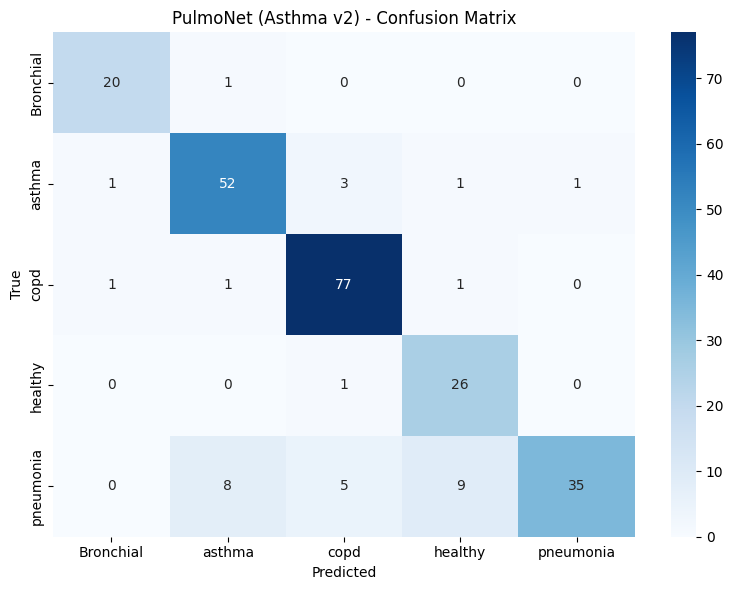

In [ ]:
# %% CELL 11 — Evaluate (THIS is the output to paste back to me)
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

val_probs = model.predict(X_val)
val_preds = np.argmax(val_probs, axis=1)

print(classification_report(y_val, val_preds, target_names=le.classes_))

cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("PulmoNet (Asthma v2) - Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/confusion_matrix_v2.png", dpi=200)
plt.show()

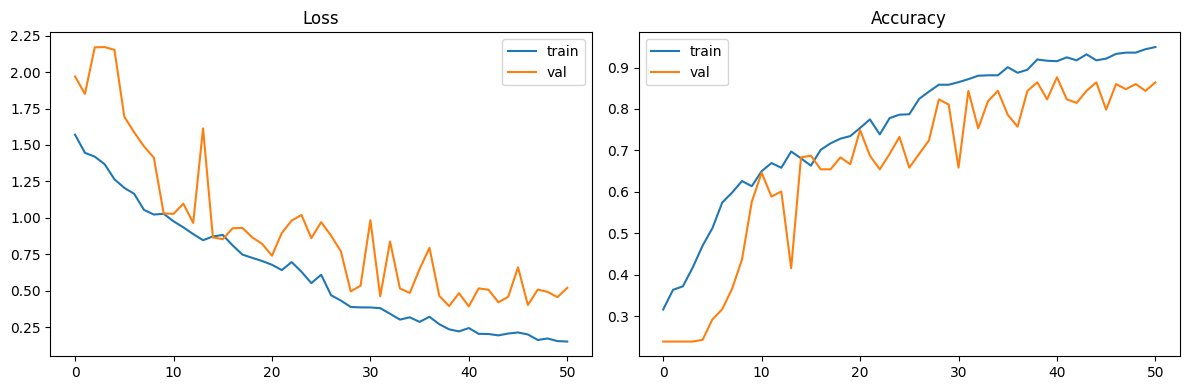

In [ ]:
# %% CELL 12 — Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/training_curves_v2.png", dpi=200)
plt.show()